# Classification Analysis - Loan Approval Prediction

### 1. Problem Statement

This project addresses one of the most critical challenges in the **banking** and **financial** sector evaluating loan applications efficiently and accurately.
Traditional manual processes are slow, inconsistent, and prone to human bias.
This project builds an automated ML pipeline to predict whether a loan should be approved or rejected based on applicant data.

## Dataset Path : https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/ClassificationAnalysis_LoanApprovalPrediction/loan_approval_dataset.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# For ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib

# For Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve

# For Warnings

import warnings
warnings.filterwarnings('ignore')


In [3]:
url = ("https://raw.githubusercontent.com/kavya12ka/Machine-Learning-Projects-Portfolio/refs/heads/main/ClassificationAnalysis_LoanApprovalPrediction/loan_approval_dataset.csv")
df = pd.read_csv(url)
df.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [4]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


(4269, 13)

In [5]:
df.describe(include = "all")

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [6]:
# finding duplicate values
print(f"Duplicate values: {df.duplicated().sum()}")

Duplicate values: 0


In [7]:
df['loan_id'].duplicated().sum()

np.int64(0)

#### Feature Selection

In [8]:
df1 = df.drop('loan_id', axis = 1)
print(f"Duplicate values: {df.duplicated().sum()}")
print("loan_id dropped successfully...")
df.shape

Duplicate values: 0
loan_id dropped successfully...


(4269, 13)

In [9]:
df1.columns

Index([' no_of_dependents', ' education', ' self_employed', ' income_annum',
       ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [10]:
df1.columns = df1.columns.str.strip()

In [11]:
for col in df1.select_dtypes(include = 'str'):
    print(col)
    print(df1[col].unique())
    print()

education
<ArrowStringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

self_employed
<ArrowStringArray>
[' No', ' Yes']
Length: 2, dtype: str

loan_status
<ArrowStringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str



In [12]:
# Cleaning the column values
df1['education'] = df1['education'].str.strip()
df1['self_employed'] = df1['self_employed'].str.strip()
df1['loan_status'] = df1['loan_status'].str.strip()

for col in df1.select_dtypes(include = 'str'):
    print(col)
    print(df1[col].unique())
    print()

education
<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

self_employed
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

loan_status
<ArrowStringArray>
['Approved', 'Rejected']
Length: 2, dtype: str



In [13]:
df1.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [14]:
# residential_assets_value -ve value handling
df1[df1['residential_assets_value']<0].head(5)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
59,4,Not Graduate,Yes,5500000,18200000,16,797,-100000,4900000,18600000,4800000,Approved
196,4,Not Graduate,Yes,400000,1500000,2,669,-100000,600000,900000,500000,Approved
559,2,Graduate,Yes,200000,500000,6,885,-100000,0,300000,200000,Rejected
702,4,Graduate,Yes,6300000,23900000,6,899,-100000,11400000,20600000,6700000,Approved
737,2,Graduate,Yes,900000,2500000,16,458,-100000,100000,3200000,1100000,Rejected


In [15]:
(df1[df1['residential_assets_value']<0]).shape[0]

28

All the residentional assents values which is negative is having 100000 in value. It is a typo and hence we drop all the 28 
values for the analysis

In [16]:
df1 = df1[df1["residential_assets_value"] >= 0]
print(f"New Data shape after removing negative values: {df1.shape}")

New Data shape after removing negative values: (4241, 12)


## Exploratory Data Analysis

#### 1. Loan Status Distribution

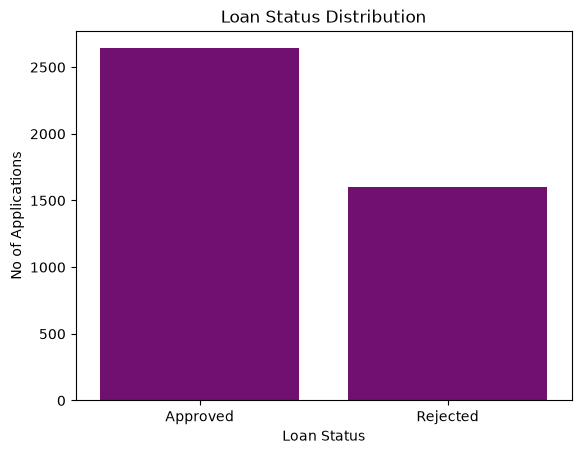

In [17]:
sns.countplot(data = df1, x = 'loan_status', color = "purple")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("No of Applications")
plt.show()

#### Loan Status and Applicant Characteristics

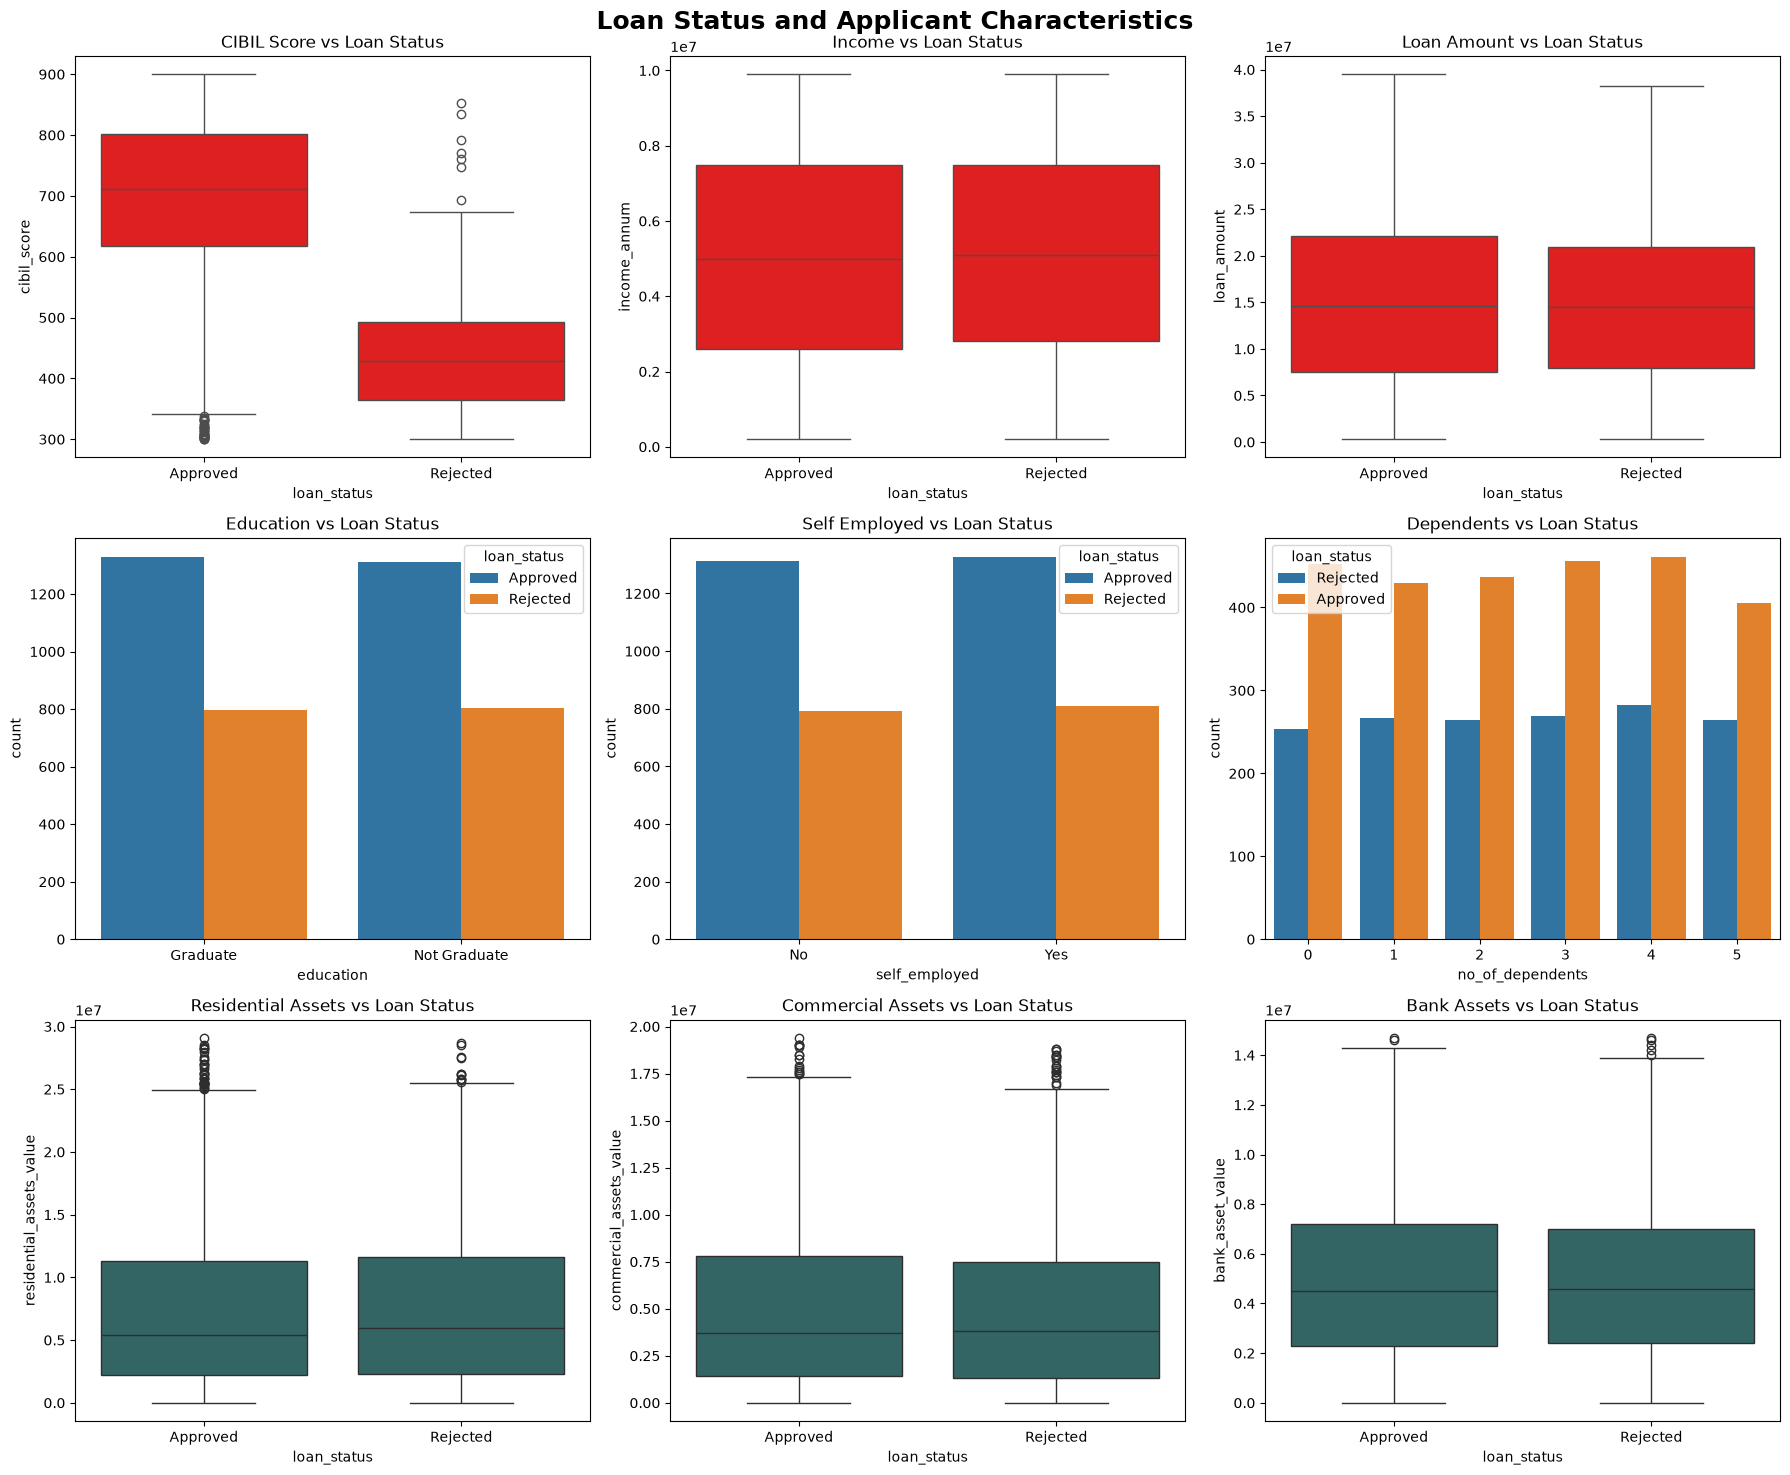

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. CIBIL Score vs Loan Status
sns.boxplot(data=df1, x='loan_status', y='cibil_score', ax=axes[0, 0],color= 'red')
axes[0, 0].set_title('CIBIL Score vs Loan Status')

# 2. Income vs Loan Status
sns.boxplot(data=df1, x='loan_status', y='income_annum', ax=axes[0, 1],color= 'red')
axes[0, 1].set_title('Income vs Loan Status')

# 3. Loan Amount vs Loan Status
sns.boxplot(data=df1, x='loan_status', y='loan_amount', ax=axes[0, 2],color= 'red')
axes[0, 2].set_title('Loan Amount vs Loan Status')

# 4. Education vs Loan Status
sns.countplot(data=df1, x='education', hue='loan_status', ax=axes[1, 0])
axes[1, 0].set_title('Education vs Loan Status')

# 5. Self Employed vs Loan Status
sns.countplot(data=df1, x='self_employed', hue='loan_status', ax=axes[1, 1])
axes[1, 1].set_title('Self Employed vs Loan Status')

# 6. Dependents vs Loan Status
sns.countplot(data=df1, x='no_of_dependents', hue='loan_status', ax=axes[1, 2])
axes[1, 2].set_title('Dependents vs Loan Status')

# 7. Residential Assets vs Loan Status
sns.boxplot(data=df1, x='loan_status',y='residential_assets_value', ax=axes[2, 0],color = "#2C6D6D")
axes[2, 0].set_title('Residential Assets vs Loan Status')

# 8. Commercial Assets vs Loan Status
sns.boxplot(data=df1, x='loan_status',y='commercial_assets_value', ax=axes[2, 1],color = "#2C6D6D")
axes[2, 1].set_title('Commercial Assets vs Loan Status')

# 9. Bank Assets vs Loan Status
sns.boxplot(data=df1, x='loan_status',y='bank_asset_value', ax=axes[2, 2],color = "#2C6D6D")
axes[2, 2].set_title('Bank Assets vs Loan Status')

fig.suptitle('Loan Status and Applicant Characteristics',fontsize = 18,fontweight = 'bold')
plt.tight_layout()
plt.show()

#### 3. Contribution of CIBIL score

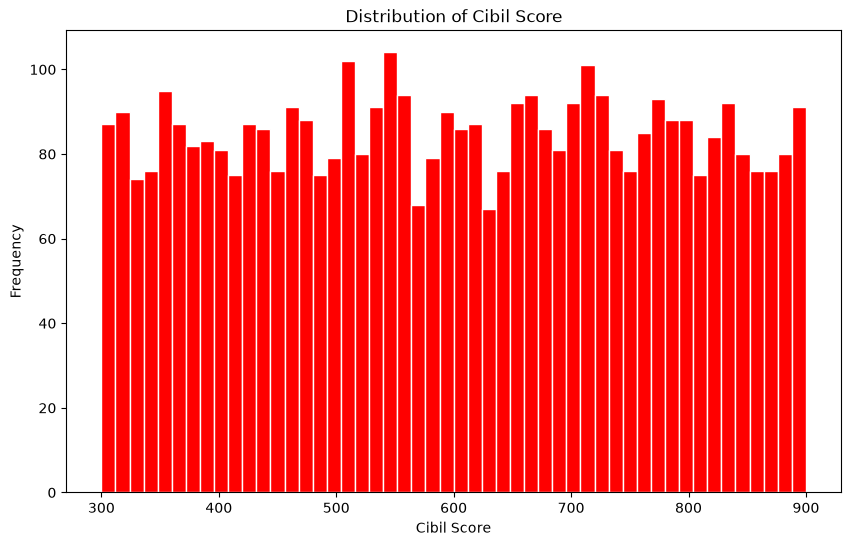

In [19]:
plt.figure(figsize=(10, 6))
plt.hist(df1['cibil_score'], bins=50, color='red', edgecolor='white')
plt.xlabel('Cibil Score')
plt.ylabel('Frequency')
plt.title('Distribution of Cibil Score')
plt.grid(True, linestyle='--', alpha =0)
plt.show()

#### Loan Status Distribution 

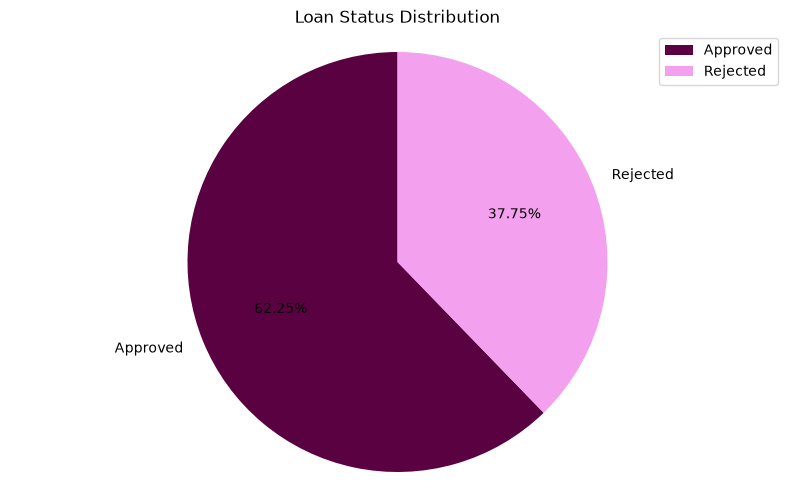

In [20]:
colors_used = ["#5A0141", "#F18DECD4"]
plt.figure(figsize=(10, 6))
plt.pie(df1['loan_status'].value_counts().values,
        labels = df1['loan_status'].value_counts().index,
        colors = colors_used[:len (df1['loan_status'].value_counts()) ],
        autopct = '%1.2f%%',
        startangle = 90
        )
plt.title('Loan Status Distribution')
plt.axis('equal')
plt.legend()
plt.show()

#### Numeric Column Distrubution

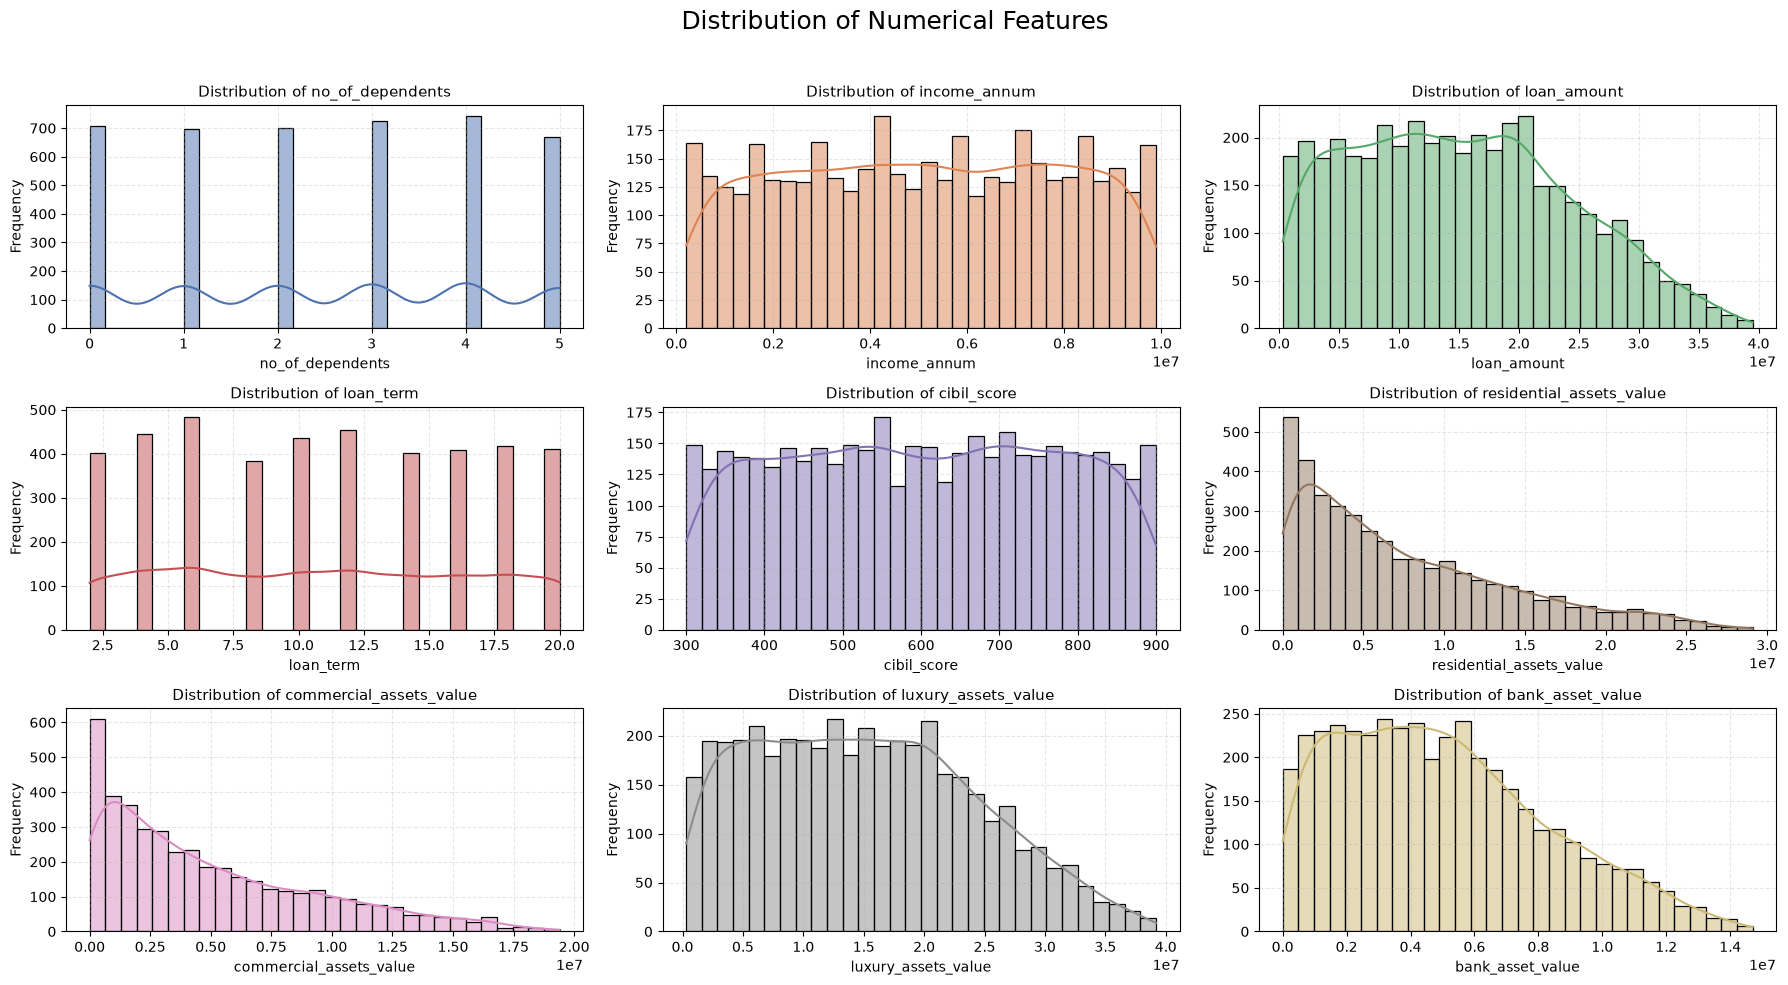

In [21]:
from numpy._core import numeric
# Distribution of Numerical columns
numeric_columns = df1.select_dtypes(include=['int64', 'float64']).columns
# setting seaborn theme
#sns.set_theme(style="whitegrid", palette ="Spectral", font_scale= 1.1)
#Distribution of all Numerical columns via Histplots
palette = sns.color_palette("deep", len(numeric_columns))

plt.figure(figsize=(18, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data = df1,x = col, color=palette[i-1], kde=True, bins=30)
    plt.title(f'Distribution of {col}',fontsize = 11)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha = 0.3)
    
plt.suptitle('Distribution of Numerical Features', fontsize = 18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Correlation Heatmap

In [22]:
df1['education'] = df1['education'].map({'Not Graduate':0,'Graduate':1})
df1['loan_status'] = df1['loan_status'].map({'Rejected':0,'Approved':1})
df1['self_employed'] = df1['self_employed'].map({'No':0,'Yes':1})

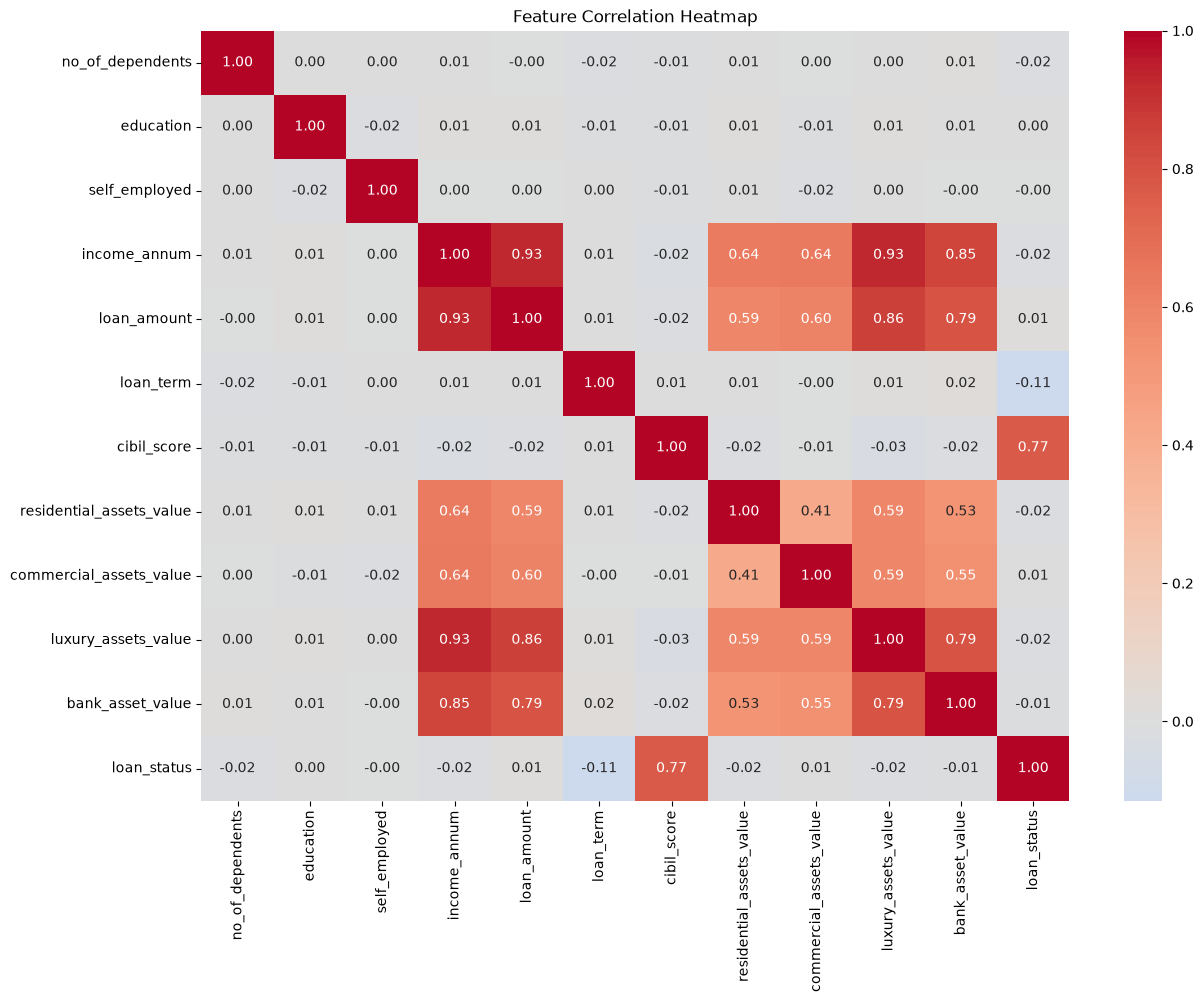

Highly correlated feature pairs (|r| > 0.8):
income_annum  luxury_assets_value    0.928698
              loan_amount            0.927083
loan_amount   luxury_assets_value    0.859928
income_annum  bank_asset_value       0.850242
dtype: float64


In [23]:
plt.figure(figsize=(14, 10))
corr = df1.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()
# Flag highly correlated pairs (|r| > 0.8)
corr_abs = corr.abs()
pairs = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool)).stack().sort_values(ascending=False))
high_corr = pairs[pairs > 0.8]
print("Highly correlated feature pairs (|r| > 0.8):")
print(high_corr)

`income_annum` is redundant with `luxury_assets_value` (r ≈ 0.93)  and `loan_amount` (r ≈ 0.93) 
`loan_amount` is redundant with `luxury_assets_value` (r ≈ 0.88) 
`income_annum` is redundant with `bank_asset_value` (r ≈ 0.85) 

-- Dropping one avoids letting that signal count twice in the distance calculation.

#### Milticollinearity Check

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_columns = df1.select_dtypes(include='number').drop(columns = 'loan_status')
vif_result = pd.DataFrame()
vif_result['Feature'] = vif_columns.columns
vif_result['VIF'] =[ variance_inflation_factor(vif_columns.values,i)
                    for i in range(vif_columns.shape[1])]
vif_result = vif_result.sort_values(by = 'VIF',ascending = False)
vif_result

,Feature,VIF
3,income_annum,17.545794
9,luxury_assets_value,7.278556
4,loan_amount,7.132761
10,bank_asset_value,3.615942
8,commercial_assets_value,1.694785
7,residential_assets_value,1.683485
0,no_of_dependents,1.001663
6,cibil_score,1.001558
2,self_employed,1.001447
5,loan_term,1.001281


In [25]:
df1["total_assets"]   = df1[["residential_assets_value","commercial_assets_value","luxury_assets_value","bank_asset_value"]].sum(axis=1)
df1["loan_to_income"] = df1["loan_amount"] / df1["income_annum"]
df1 = df1.drop(columns=["residential_assets_value","commercial_assets_value","luxury_assets_value","bank_asset_value","income_annum","loan_amount"])
df1.head()

,no_of_dependents,education,self_employed,loan_term,cibil_score,loan_status,total_assets,loan_to_income
0,2,1,0,12,778,1,50700000,3.114583
1,0,0,1,8,417,0,17000000,2.975610
2,3,1,0,20,506,0,57700000,3.263736
3,3,1,0,8,467,0,52700000,3.743902
4,5,0,1,20,382,0,55000000,2.469388


In [26]:
df1.head()

,no_of_dependents,education,self_employed,loan_term,cibil_score,loan_status,total_assets,loan_to_income
0,2,1,0,12,778,1,50700000,3.114583
1,0,0,1,8,417,0,17000000,2.975610
2,3,1,0,20,506,0,57700000,3.263736
3,3,1,0,8,467,0,52700000,3.743902
4,5,0,1,20,382,0,55000000,2.469388


#### Prepare the dataset

In [27]:
X =  df1.drop(columns = ['loan_status'])
y = df1['loan_status']
print(X.shape,y.shape)

(4241, 7) (4241,)


#### Train Split Test

In [28]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42, stratify = y)
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)


X_train shape: (3392, 7)
X_test shape: (849, 7)
y_train shape: (3392,)
y_test shape: (849,)


In [29]:
y_train.value_counts()

loan_status
1    2112
0    1280
Name: count, dtype: int64

There is imbalance in dataset .The model may be biased towards the Accepted(1)

Methods to balance the data set - Random sampler - Random Over Sampler & Radom Under Sampler, SMOTE

#### SMOTE - Synthetic Minority Over Sampling Technique

In [30]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
X_train_bal,y_train_bal = smote.fit_resample(X_train,y_train)
print(y_train_bal.value_counts())
print("Shape before balancing:",X_train.shape)
print("Shape after balancing:",X_train_bal.shape)

loan_status
1    2112
0    2112
Name: count, dtype: int64
Shape before balancing: (3392, 7)
Shape after balancing: (4224, 7)


#### Numerical Transformer - Standard Scalar

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

#### Logistic Regression Model

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score, roc_auc_score

log_model = LogisticRegression(max_iter = 1000,random_state = 42)
log_model.fit(X_train_scaled,y_train_bal)
y_pred = log_model.predict(X_test_scaled)

# evaluate
print("Accuracy:\n",accuracy_score(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Precision Score:\n",precision_score(y_test,y_pred))
print("f1 Score:\n",f1_score(y_test,y_pred))
print("Recall Score:\n",recall_score(y_test,y_pred))
y_prob = log_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9305064782096584
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       321
           1       0.94      0.95      0.94       528

    accuracy                           0.93       849
   macro avg       0.93      0.93      0.93       849
weighted avg       0.93      0.93      0.93       849

Confusion Matrix:
 [[290  31]
 [ 28 500]]
Precision Score:
 0.9416195856873822
f1 Score:
 0.9442870632672332
Recall Score:
 0.946969696969697
ROC AUC Score:
 0.9774379307089587


#### KNN (K-Nearest Neighbors) Model

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled,y_train_bal)
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate
print("Accuracy:\n",accuracy_score(y_test,y_pred_knn))
print("Classification Report:\n",classification_report(y_test,y_pred_knn))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_knn))
print("Precision Score:\n",precision_score(y_test,y_pred_knn))
print("f1 Score:\n",f1_score(y_test,y_pred_knn))
print("Recall Score:\n",recall_score(y_test,y_pred_knn))
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]
auc = roc_auc_score(y_test,y_prob_knn)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9222614840989399
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       321
           1       0.95      0.92      0.94       528

    accuracy                           0.92       849
   macro avg       0.91      0.92      0.92       849
weighted avg       0.92      0.92      0.92       849

Confusion Matrix:
 [[298  23]
 [ 43 485]]
Precision Score:
 0.9547244094488189
f1 Score:
 0.9362934362934363
Recall Score:
 0.9185606060606061
ROC AUC Score:
 0.9768095676390068


#### Decision Tree Model 

In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train_bal,y_train_bal)
y_pred_dt = dt_model.predict(X_test)

# Evaluate
print("Accuracy:\n",accuracy_score(y_test,y_pred_dt))
print("Classification Report:\n",classification_report(y_test,y_pred_dt))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_dt))
print("Precision Score:\n",precision_score(y_test,y_pred_dt))
print("f1 Score:\n",f1_score(y_test,y_pred_dt))
print("Recall Score:\n",recall_score(y_test,y_pred_dt))
y_prob_df = dt_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,y_prob_df)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9917550058892816
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       321
           1       0.99      0.99      0.99       528

    accuracy                           0.99       849
   macro avg       0.99      0.99      0.99       849
weighted avg       0.99      0.99      0.99       849

Confusion Matrix:
 [[317   4]
 [  3 525]]
Precision Score:
 0.9924385633270322
f1 Score:
 0.9933774834437086
Recall Score:
 0.9943181818181818
ROC AUC Score:
 0.9909285613140753


#### Random Forest Model

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train_bal,y_train_bal)
y_pred_rf= rf_model.predict(X_test)

# Evaluate
print("Accuracy:\n",accuracy_score(y_test,y_pred_rf))
print("Classification Report:\n",classification_report(y_test,y_pred_rf))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_rf))
print("Precision Score:\n",precision_score(y_test,y_pred_rf))
print("f1 Score:\n",f1_score(y_test,y_pred_rf))
print("Recall Score:\n",recall_score(y_test,y_pred_rf))
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test,y_prob_rf)
print("ROC AUC Score:\n",auc)

Accuracy:
 0.9952885747938751
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       321
           1       0.99      1.00      1.00       528

    accuracy                           1.00       849
   macro avg       1.00      0.99      0.99       849
weighted avg       1.00      1.00      1.00       849

Confusion Matrix:
 [[317   4]
 [  0 528]]
Precision Score:
 0.9924812030075187
f1 Score:
 0.9962264150943396
Recall Score:
 1.0
ROC AUC Score:
 0.9956132587557821


#### Compare the model

In [36]:
from sklearn.metrics import roc_curve

summary_rows = [
    {"Model": "Logistic Regression", 
     "Accuracy": accuracy_score(y_test, y_pred),
     "Precision": precision_score(y_test, y_pred), 
     "Recall": recall_score(y_test, y_pred),
     "F1": f1_score(y_test, y_pred), 
     "ROC AUC": roc_auc_score(y_test, y_prob)},
    {"Model": "KNN", 
     "Accuracy": accuracy_score(y_test, y_pred_knn),
     "Precision": precision_score(y_test, y_pred_knn), 
     "Recall": recall_score(y_test, y_pred_knn),
     "F1": f1_score(y_test, y_pred_knn), 
     "ROC AUC": roc_auc_score(y_test, y_prob_knn)},
    {"Model": "Decision Tree", 
     "Accuracy": accuracy_score(y_test, y_pred_dt),
     "Precision": precision_score(y_test, y_pred_dt), 
     "Recall": recall_score(y_test, y_pred_dt),
     "F1": f1_score(y_test, y_pred_dt), 
     "ROC AUC": roc_auc_score(y_test, y_prob_df)},
    {"Model": "Random Forest", 
     "Accuracy": accuracy_score(y_test, y_pred_rf),
     "Precision": precision_score(y_test, y_pred_rf), 
     "Recall": recall_score(y_test, y_pred_rf),
     "F1": f1_score(y_test, y_pred_rf), 
     "ROC AUC": roc_auc_score(y_test, y_prob_rf)}
    ]

model_comparison = pd.DataFrame(summary_rows).set_index("Model").round(4)
model_comparison.sort_values("Recall", ascending=False)

,Accuracy,Precision,Recall,F1,ROC AUC
Model,,,,,
Random Forest,0.9953,0.9925,1.0000,0.9962,0.9956
Decision Tree,0.9918,0.9924,0.9943,0.9934,0.9909
Logistic Regression,0.9305,0.9416,0.9470,0.9443,0.9774
KNN,0.9223,0.9547,0.9186,0.9363,0.9768


#### Classification Report for Best Model - Random Forest

In [37]:
print("=" * 55)
print(f" {' '*8} Classification Report -Random Forest Model")
print("=" * 55)
print(classification_report(y_test, y_pred_rf))


          Classification Report -Random Forest Model
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       321
           1       0.99      1.00      1.00       528

    accuracy                           1.00       849
   macro avg       1.00      0.99      0.99       849
weighted avg       1.00      1.00      1.00       849



#### Confusion Matrix

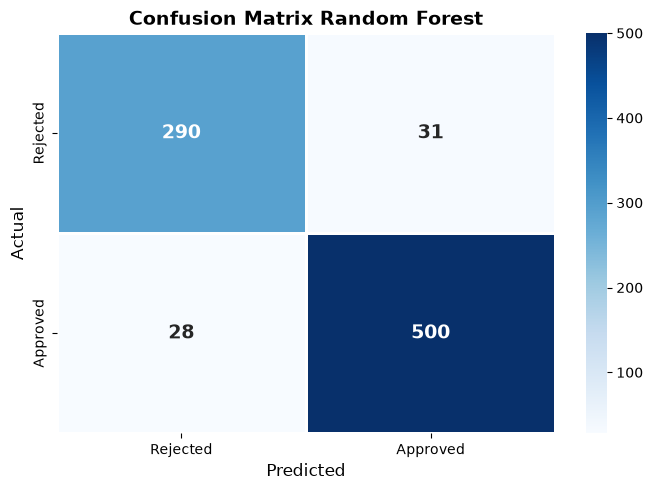

In [38]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix Random Forest", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

#### ROC Curve

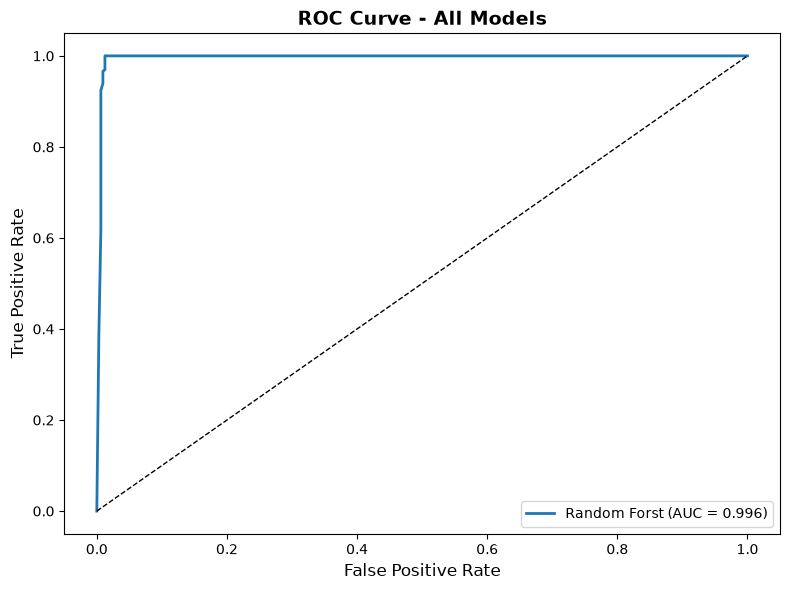

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))


auc = roc_auc_score(y_test,y_prob_rf)
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
ax.plot(fpr, tpr, label=f"Random Forst (AUC = {auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", linewidth=1)
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - All Models", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Model Deployment

In [40]:
import joblib
joblib.dump(rf_model,"loan_prediction_model.pkl")
#joblib.dump(scaler,"scaler.pkl")

print("Best model saved successfully...")

Best model saved successfully...


In [41]:
model = joblib.load("loan_prediction_model.pkl")
#scaler = joblib.load("scaler.pkl")

In [42]:
# sample applicants Data

sample_applicants = pd.DataFrame({
    "no_of_dependents"        : [0, 2, 4, 1, 3],
    "education"               : [1, 1, 0, 0, 1],
    "self_employed"           : [0, 0, 1, 0, 1],
    "loan_term"               : [8, 12, 20, 6, 16],
    "cibil_score"             : [800, 650, 400, 750, 500],
    "total_assets"            : [75000000, 28000000, 1000000, 42000000, 32000000],
    "loan_to_income"          : [1.0,2.5,3.5,2.9,1.2]
})

applicant_names = [
    "Applicant A - High Income",
    "Applicant B - Average Profile",
    "Applicant C - Low Income",
    "Applicant D - Good Credit",
    "Applicant E - High Risk"
]

print("Sample applicants created.")
sample_applicants

Sample applicants created.


,no_of_dependents,education,self_employed,loan_term,cibil_score,total_assets,loan_to_income
0,0,1,0,8,800,75000000,1.0
1,2,1,0,12,650,28000000,2.5
2,4,0,1,20,400,1000000,3.5
3,1,0,0,6,750,42000000,2.9
4,3,1,1,16,500,32000000,1.2


In [43]:
predictions     = model.predict(sample_applicants)
probabilities   = model.predict_proba(sample_applicants)

prob_approved   = [f"{p[1]*100:.1f}%" for p in probabilities]
prob_rejected   = [f"{p[0]*100:.1f}%" for p in probabilities]
decision        = ["APPROVED" if p == 1 else "REJECTED" for p in predictions]

results_df = pd.DataFrame({
    "Applicant"        : applicant_names,
    "CIBIL Score"      : sample_applicants["cibil_score"].values,
    "Loan Term (yrs)"  : sample_applicants["loan_term"].values,
    "Prob Approved"    : prob_approved,
    "Prob Rejected"    : prob_rejected,
    "Decision"         : decision
})

results_df.set_index("Applicant", inplace=True)
results_df

,CIBIL Score,Loan Term (yrs),Prob Approved,Prob Rejected,Decision
Applicant,,,,,
Applicant A - High Income,800,8,98.0%,2.0%,APPROVED
Applicant B - Average Profile,650,12,100.0%,0.0%,APPROVED
Applicant C - Low Income,400,20,6.0%,94.0%,REJECTED
Applicant D - Good Credit,750,6,98.0%,2.0%,APPROVED
Applicant E - High Risk,500,16,2.0%,98.0%,REJECTED
